Balance Risk Distribution (Threshold > 580):
is_balance_risk
0    0.933659
1    0.066341
Name: proportion, dtype: float64
Tuning Logistic Regression...
Tuning Random Forest...
Logistic Regression Mean CV F1-Score: 0.8381
Random Forest Mean CV F1-Score: 0.9121


C:\Users\User\AppData\Local\Temp\ipykernel_28560\2688585477.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coeffs.values[:10], y=coeffs.index[:10], ax=ax[1], palette="coolwarm")


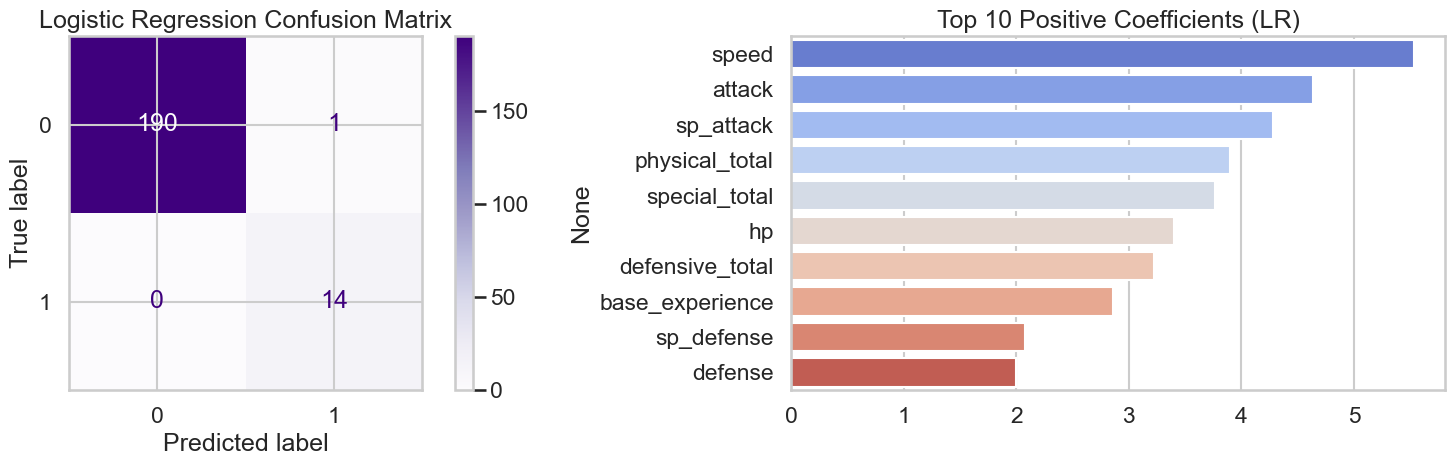

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       191
           1       0.93      1.00      0.97        14

    accuracy                           1.00       205
   macro avg       0.97      1.00      0.98       205
weighted avg       1.00      1.00      1.00       205



C:\Users\User\AppData\Local\Temp\ipykernel_28560\2688585477.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values[:10], y=importances.index[:10], ax=ax[1], palette="magma")


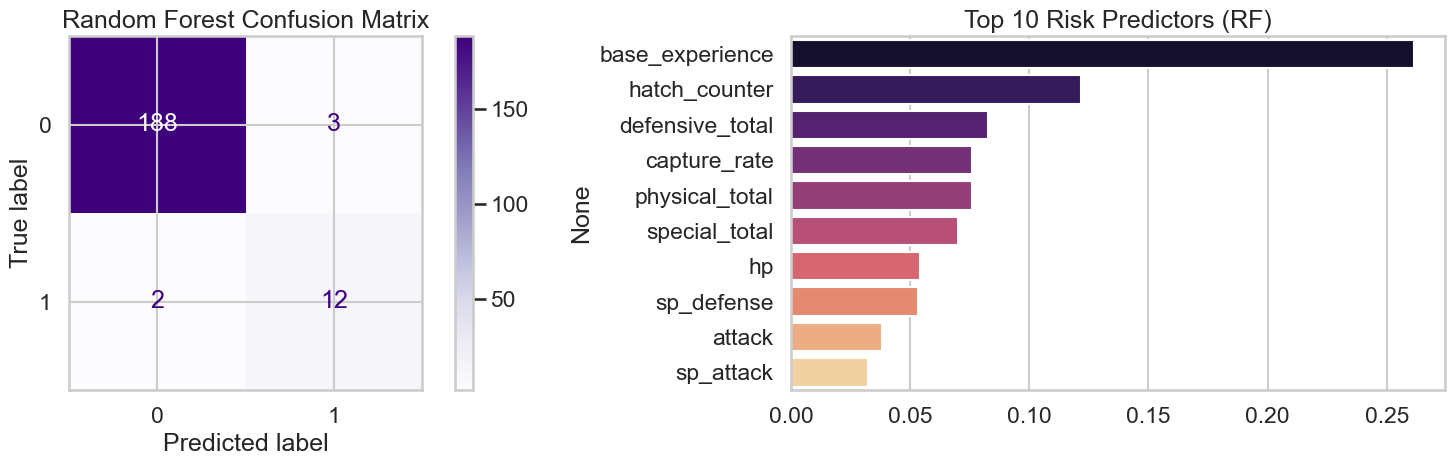

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       191
           1       0.80      0.86      0.83        14

    accuracy                           0.98       205
   macro avg       0.89      0.92      0.91       205
weighted avg       0.98      0.98      0.98       205

Both pipelines saved successfully to the /models directory.


In [3]:
# %% [markdown]
# # Balance Risk Modeling: Logistic Regression vs. Random Forest
# This notebook builds two competitive models to assist Game Developers in identifying balance risks.
# It includes Hyperparameter Tuning and K-Fold Cross-Validation for both.

# %% [code]
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from joblib import dump

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Formatting for presentation
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

# %% [code]
# 1. Data Loading
data_path = Path("..") / "data" / "final_processed_dataset.csv"
df = pd.read_csv(data_path)

# %% [code]
# 2. Target Labeling (Refined Proxy)
# 580 is the threshold for 'Sub-Legendary' power levels.
threshold = 580
df["is_balance_risk"] = (df["base_stat_total"] > threshold).astype(int)

print(f"Balance Risk Distribution (Threshold > {threshold}):")
print(df["is_balance_risk"].value_counts(normalize=True))

# %% [code]
# 3. Feature Selection & Preventing Data Leakage
# CRITICAL: Drop 'base_stat_total' and 'offensive_total' as they define the target.
X = df.drop(columns=["pokedex_id", "is_balance_risk", "base_stat_total", "offensive_total"])
y = df["is_balance_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# %% [code]
# 4. Model 1: Logistic Regression (Hyperparameter Tuning)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
])

lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2']
}

print("Tuning Logistic Regression...")
lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=5, scoring='f1')
lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_

# %% [code]
# 5. Model 2: Random Forest (Hyperparameter Tuning)
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(class_weight="balanced", random_state=42))
])

rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10],
    'classifier__min_samples_leaf': [1, 2]
}

print("Tuning Random Forest...")
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='f1')
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

# %% [code]
# 6. K-Fold Cross-Validation (Comparing Both)
models = {"Logistic Regression": best_lr, "Random Forest": best_rf}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    print(f"{name} Mean CV F1-Score: {cv_scores.mean():.4f}")

# %% [code]
# 7. Final Evaluation & Visualizations
for name, model in models.items():
    y_pred = model.predict(X_test)
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    
    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap="Purples")
    ax[0].set_title(f"{name} Confusion Matrix")
    
    # Feature Insights
    if name == "Random Forest":
        importances = pd.Series(model.named_steps['classifier'].feature_importances_, index=X.columns).sort_values(ascending=False)
        sns.barplot(x=importances.values[:10], y=importances.index[:10], ax=ax[1], palette="magma")
        ax[1].set_title("Top 10 Risk Predictors (RF)")
    else:
        coeffs = pd.Series(model.named_steps['classifier'].coef_[0], index=X.columns).sort_values(ascending=False)
        sns.barplot(x=coeffs.values[:10], y=coeffs.index[:10], ax=ax[1], palette="coolwarm")
        ax[1].set_title("Top 10 Positive Coefficients (LR)")

    plt.tight_layout()
    plt.show()
    print(f"--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))

# %% [code]
# 8. Export Both Pipelines for Deployment (Member 6)
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

dump(best_lr, models_dir / "balance_risk_lr_pipeline.joblib")
dump(best_rf, models_dir / "balance_risk_rf_pipeline.joblib")

print("Both pipelines saved successfully to the /models directory.")